# Experiments and results

In [1]:
from utils import prox_mcp, mcp, mcp_torch, lmo_spectral, lmo_nuclear

from experiments import (
    run_experiment, plot_scaling, plot_images, plot_loss, plot_smoothing_loss,
    plot_primal_gap_and_penalty, plot_images_ranks,
)

import numpy as np
import torch


## Chose the dataset

Uncomment the line corresponding to the dataset you want to use

In [2]:
dataset = 'camera'
# dataset = "spectrometer"
# dataset = "olivetti" 
# dataset = "football"
# dataset = "miserables"
# dataset = "low_rank_synthetic"

K = 10_000 if dataset == 'olivetti' else 5_000
store_WH_every = 100 if dataset == 'olivetti' else 1
g = lambda W : np.sum(mcp(W))
g_torch = lambda W : torch.sum(mcp_torch(W))
prox = prox_mcp
lmo = lambda M : lmo_spectral(M, 1., 6)
# lmo = lambda M : lmo_nuclear(M, 1.)
comment = ""
save = False

## Dataset

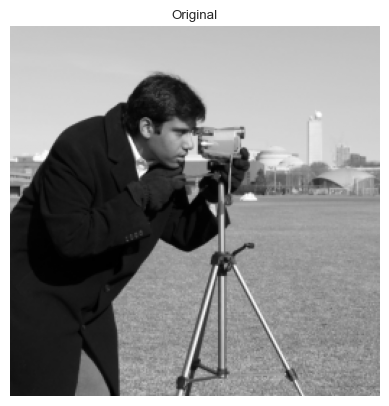

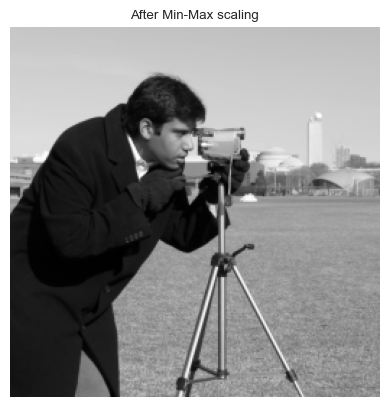

Dataset shape: (256, 256)


In [3]:
plot_scaling(dataset)

## Experiments with rank = 10

### Run algorithms

In [4]:
results10 = run_experiment(
    dataset, 
    K = K, 
    g = g,
    g_torch = g_torch,
    prox = prox,
    lmo = lmo,
    comment = comment,
    save = save,
)

100%|██████████| 5000/5000 [00:02<00:00, 2108.54it/s]


melmo (p = 2/3. q = 1/4) loss: 311.4610509773762


100%|██████████| 5000/5000 [00:01<00:00, 3975.75it/s]


melmo (p = 7/12. q = 1/3) loss: 311.585006480659


100%|██████████| 5000/5000 [00:02<00:00, 1880.06it/s]


Subgradient descent loss: 360.3185729980469


100%|██████████| 5000/5000 [00:00<00:00, 5431.22it/s]

Variable Smoothing BW loss: 312.7350865830659


### Show the final images

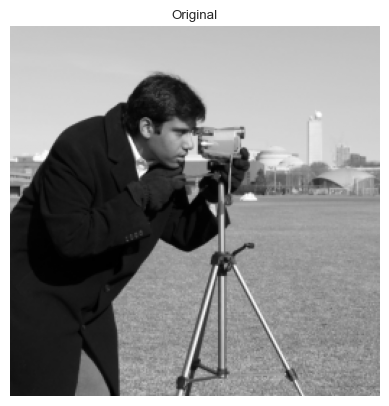

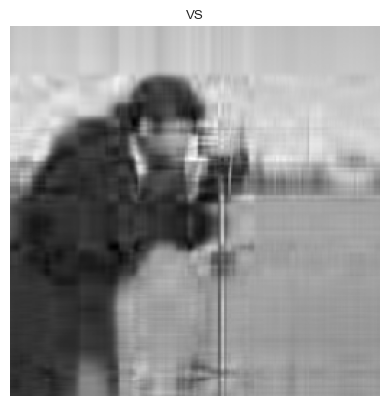

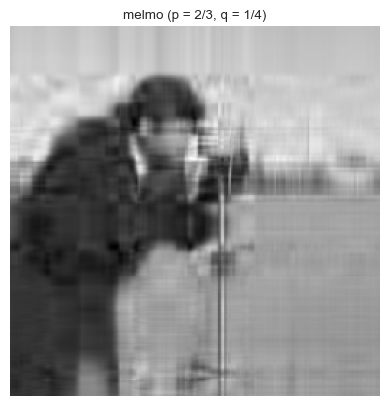

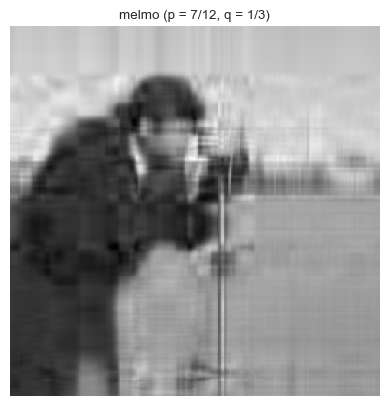

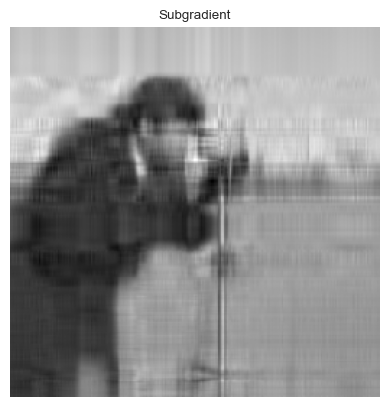

In [5]:
plot_images(results10)

### Plot the reconstruction loss

In [6]:
# print(results10['melmo (p = 2/3, q = 1/3)']['loss'].min()/results10['norm'])
print(results10['melmo (p = 7/12, q = 1/3)']['loss'].min()/results10['norm'])
print(results10['melmo (p = 2/3, q = 1/4)']['loss'].min()/results10['norm'])

0.014181904651920377
0.014178218694680151


VS : 1.424e-02
melmo (p = 2/3. q = 1/4) : 1.418e-02
melmo (p = 7/12. q = 1/3) : 1.418e-02
Subgradient : 1.640e-02


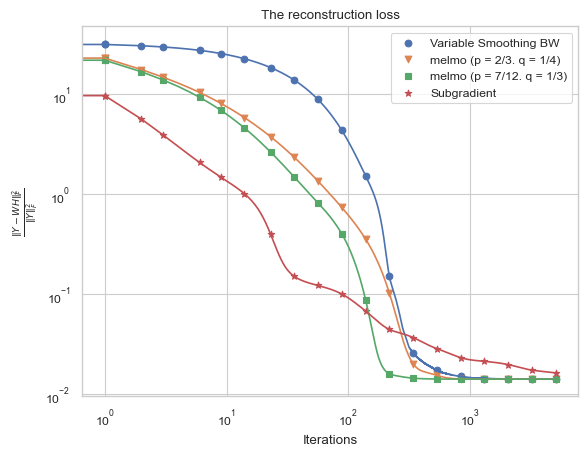

In [7]:
plot_loss(results10)

### Plot the smoothing loss

VS : 2.938e+00
melmo (p = 2/3. q = 1/4) : 3.457e+00
melmo (p = 7/12. q = 1/3) : 2.135e+00


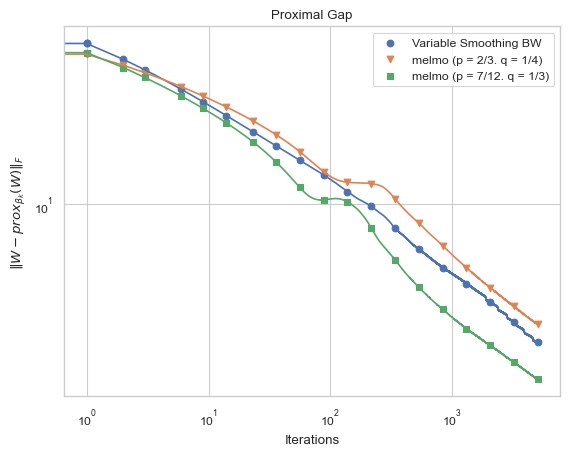

In [8]:
plot_smoothing_loss(results10)

### Plot the primal gap and penalty

VS : 5.135e+02
melmo (p = 2/3. q = 1/4) : 4.484e+02
melmo (p = 7/12. q = 1/3) : 4.151e+02
Subgradient : 5.778e+02


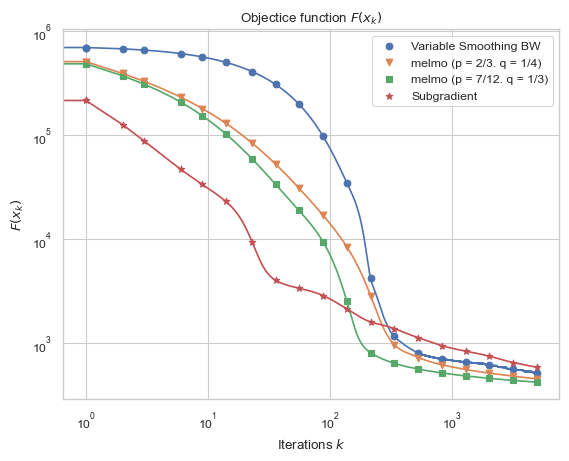

VS : 2.008e+02
melmo (p = 2/3. q = 1/4) : 1.370e+02
melmo (p = 7/12. q = 1/3) : 1.035e+02


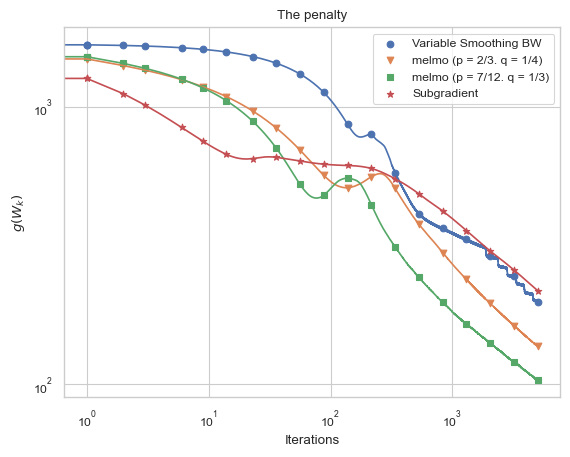

In [9]:
plot_primal_gap_and_penalty(results10)

## Experiments with rank = 20

### Run algorithms

In [10]:
results20 = run_experiment(
    dataset, 
    rank = 20, 
    K = K, 
    g = g, 
    g_torch = g_torch,
    prox = prox,
    lmo = lmo,
    comment = comment,
    save = save,
)

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:02<00:00, 2473.32it/s]


melmo (p = 2/3. q = 1/4) loss: 145.54029113488232


100%|██████████| 5000/5000 [00:01<00:00, 2526.57it/s]


melmo (p = 7/12. q = 1/3) loss: 145.80847141825183


100%|██████████| 5000/5000 [00:02<00:00, 1668.34it/s]


Subgradient descent loss: 236.15426635742188


100%|██████████| 5000/5000 [00:01<00:00, 4407.61it/s]

Variable Smoothing BW loss: 153.0273221620846


### Show the final images

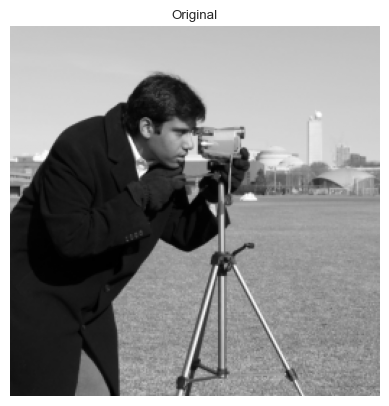

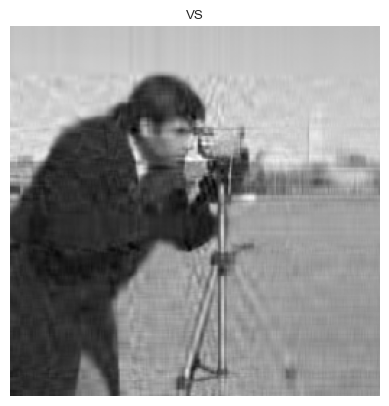

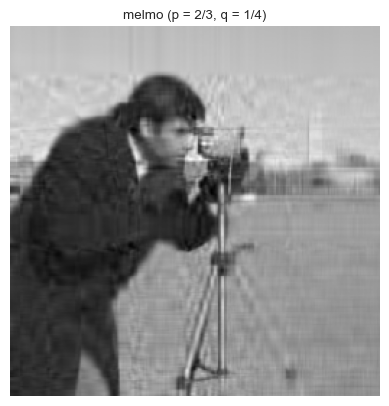

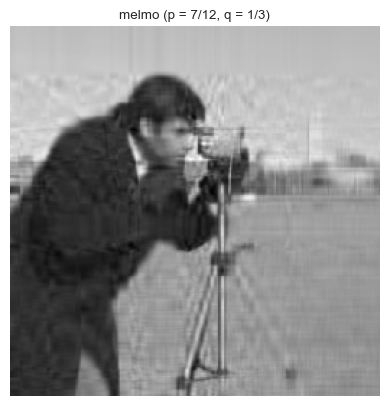

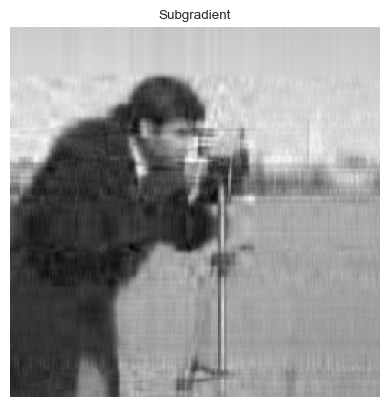

In [11]:
plot_images(results20)

### Plot the reconstruction loss

In [12]:
# print(results20['melmo (p = 2/3, q = 1/3)']['loss'].min()/results20['norm'])
print(results20['melmo (p = 7/12, q = 1/3)']['loss'].min()/results20['norm'])
print(results20['melmo (p = 2/3, q = 1/4)']['loss'].min()/results20['norm'])


0.006634084125518763
0.006624822055265807


VS : 6.966e-03
melmo (p = 2/3. q = 1/4) : 6.625e-03
melmo (p = 7/12. q = 1/3) : 6.638e-03
Subgradient : 1.075e-02


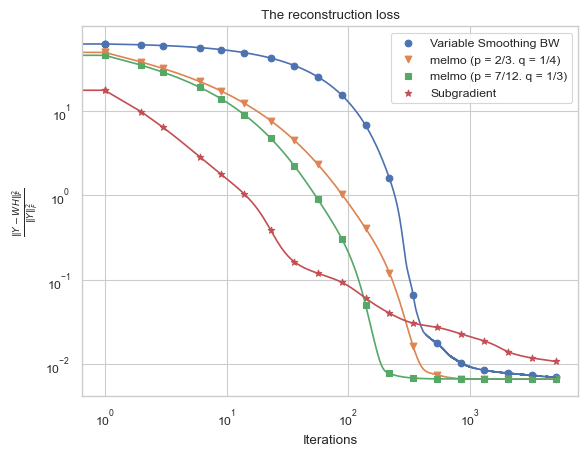

In [13]:
plot_loss(results20)

### Plot the smoothing loss

VS : 3.764e+00
melmo (p = 2/3. q = 1/4) : 3.661e+00
melmo (p = 7/12. q = 1/3) : 2.470e+00


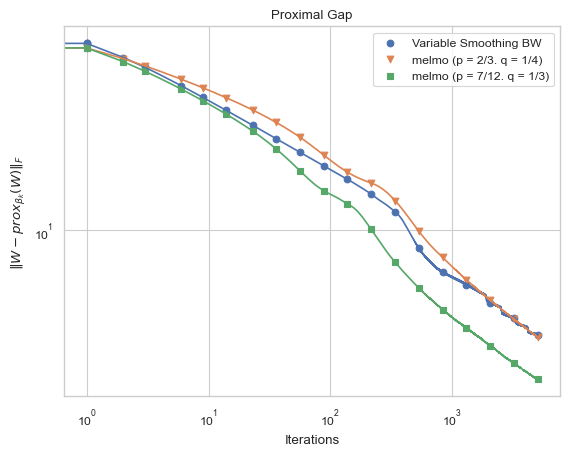

In [14]:
plot_smoothing_loss(results20)

### Plot the primal gap and penalty

VS : 4.362e+02
melmo (p = 2/3. q = 1/4) : 3.527e+02
melmo (p = 7/12. q = 1/3) : 2.963e+02
Subgradient : 5.051e+02


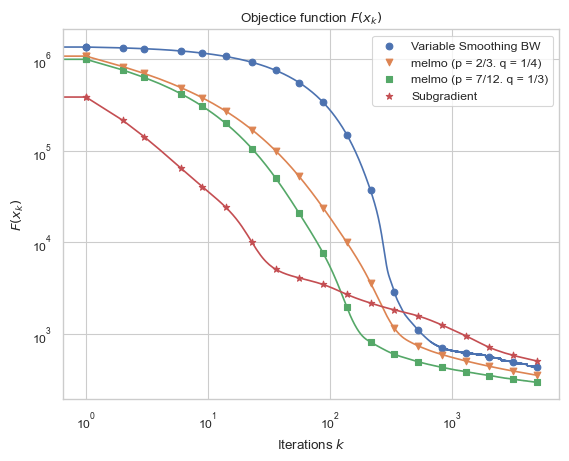

VS : 2.832e+02
melmo (p = 2/3. q = 1/4) : 2.072e+02
melmo (p = 7/12. q = 1/3) : 1.505e+02


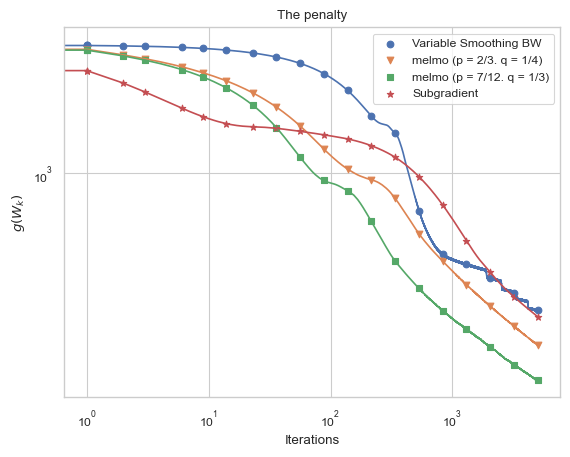

In [15]:
plot_primal_gap_and_penalty(results20)

## Experiments with rank = 30

### Run algorithms

In [16]:
results30 = run_experiment(
    dataset, 
    rank = 30, 
    K = K, 
    g = g, 
    g_torch = g_torch,
    prox = prox,
    lmo = lmo,
    comment = comment,
    save = save,
)

100%|██████████| 5000/5000 [00:02<00:00, 2088.08it/s]


melmo (p = 2/3. q = 1/4) loss: 81.75720921640756


100%|██████████| 5000/5000 [00:02<00:00, 2060.07it/s]


melmo (p = 7/12. q = 1/3) loss: 82.18143637338017


100%|██████████| 5000/5000 [00:02<00:00, 1720.88it/s]


Subgradient descent loss: 184.2603759765625


100%|██████████| 5000/5000 [00:01<00:00, 4543.75it/s]

Variable Smoothing BW loss: 98.99289296560524


### Show the final images

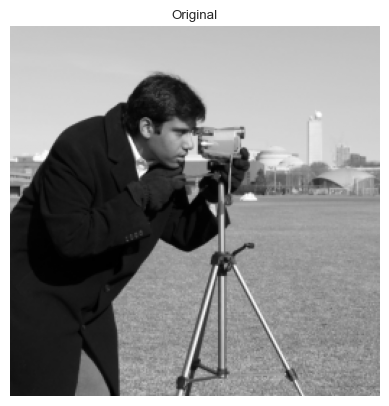

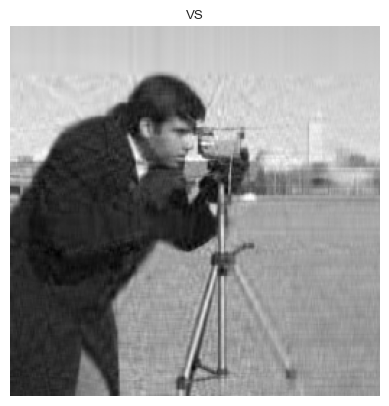

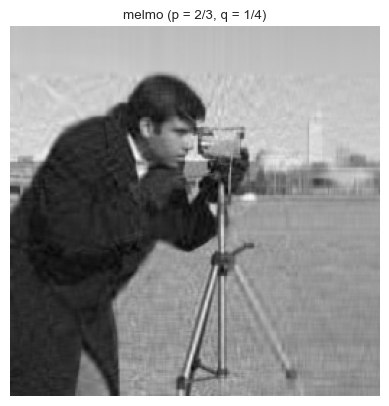

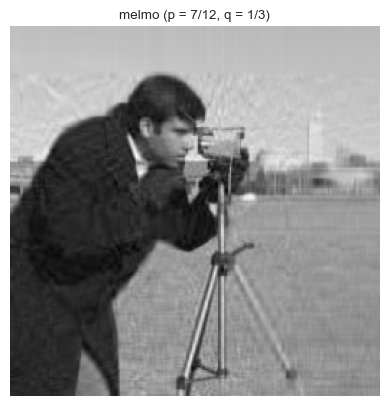

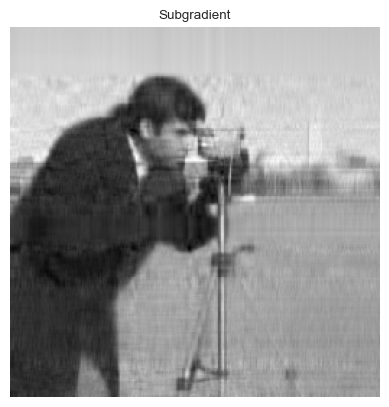

In [17]:
plot_images(results30)

### Plot the reconstruction loss

In [18]:
# print(results30['melmo (p = 2/3, q = 1/3)']['loss'].min()/results10['norm'])
print(results30['melmo (p = 7/12, q = 1/3)']['loss'].min()/results10['norm'])
print(results30['melmo (p = 2/3, q = 1/4)']['loss'].min()/results10['norm'])

0.003730622836071989
0.0037183608850321994


VS : 4.506e-03
melmo (p = 2/3. q = 1/4) : 3.722e-03
melmo (p = 7/12. q = 1/3) : 3.741e-03
Subgradient : 8.388e-03


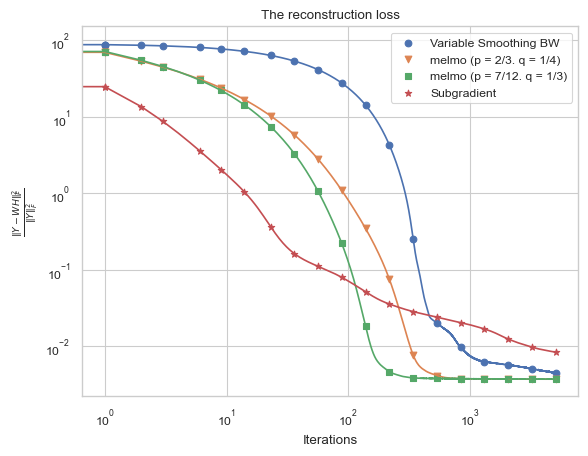

In [19]:
plot_loss(results30)

### Plot the smoothing loss

VS : 3.939e+00
melmo (p = 2/3. q = 1/4) : 3.617e+00
melmo (p = 7/12. q = 1/3) : 2.669e+00


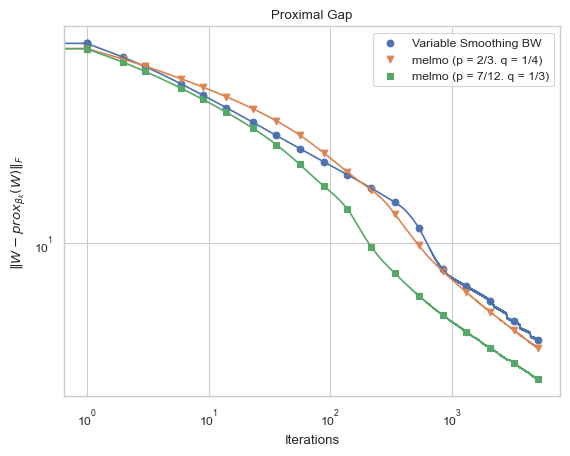

In [20]:
plot_smoothing_loss(results30)

### Plot the primal gap and penalty

VS : 4.336e+02
melmo (p = 2/3. q = 1/4) : 3.320e+02
melmo (p = 7/12. q = 1/3) : 2.692e+02
Subgradient : 4.783e+02


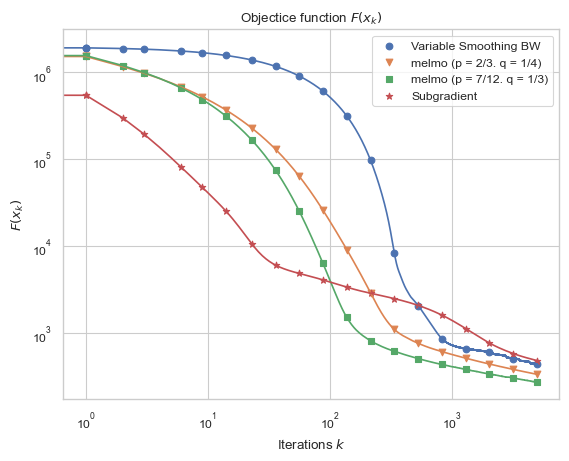

VS : 3.346e+02
melmo (p = 2/3. q = 1/4) : 2.502e+02
melmo (p = 7/12. q = 1/3) : 1.870e+02


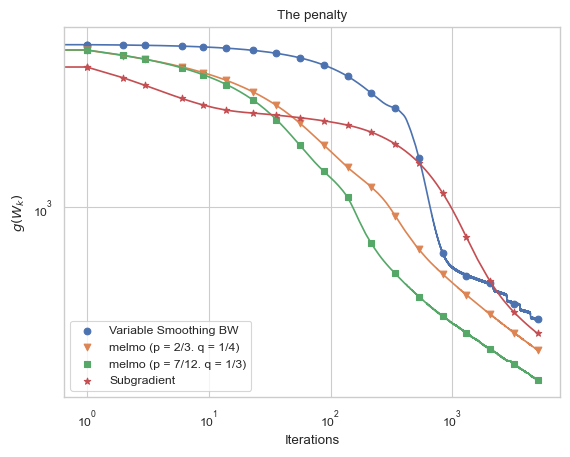

In [21]:
plot_primal_gap_and_penalty(results30)

## Comparison of the images between the ranks

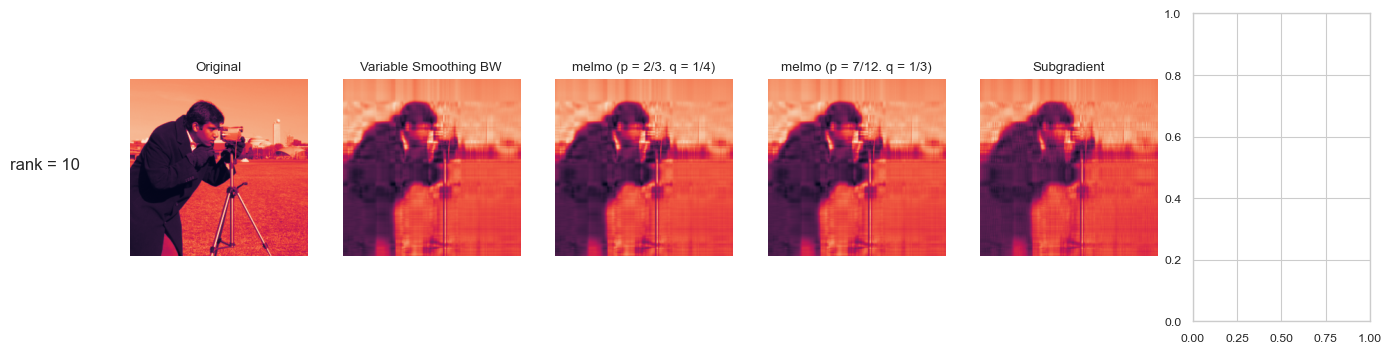

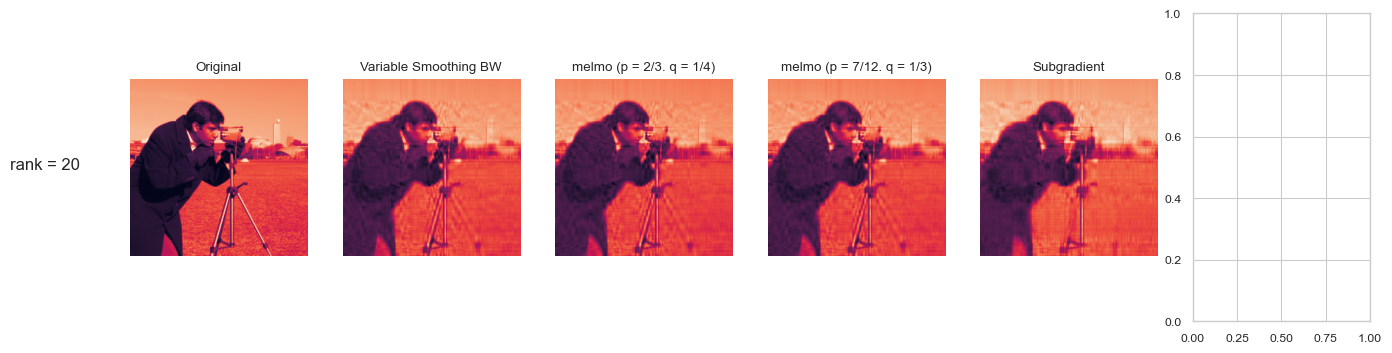

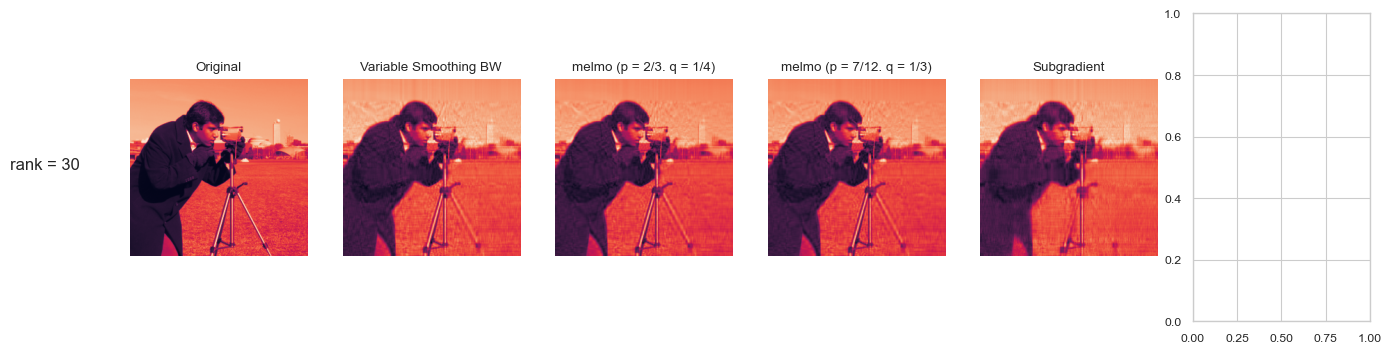

In [22]:
plot_images_ranks({
    10: results10,
    20: results20,
    30: results30,
})

## NS2 vs NS6

Gap melmo (p = 2/3. q = 1/4) : 1.860e+01
melmo (p = 7/12. q = 1/3) : 3.917e+02
Gap melmo (p = 7/12. q = 1/3) : -8.092e-01


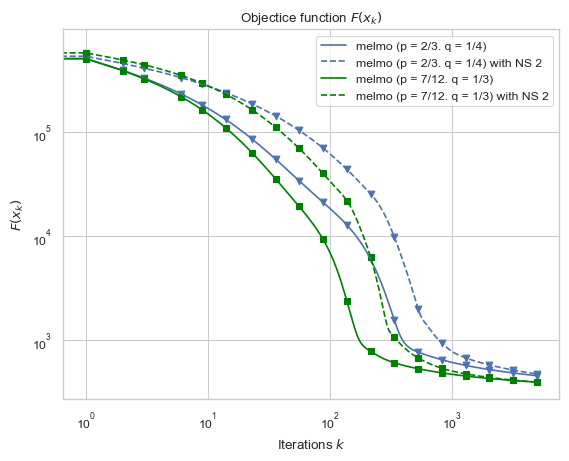

In [23]:
import pickle
import matplotlib.pyplot as plt
rank = 10
with open(f'results/{dataset}/{dataset}_rank{rank}.pkl', 'rb') as f:
    results_NS6 = pickle.load(f)

with open(f'results/{dataset}/{dataset}_rank{rank}_NS2.pkl', 'rb') as f:
    results_NS2 = pickle.load(f)
    
K = results_NS6['K']
scatter_period = K // 20
D = results_NS6['original']

x = np.arange(K)[::scatter_period]
x = np.logspace(0, np.log10(K-1), num=len(x), endpoint=True).astype(int)

g_NSD6 = results_NS6['gamons (p = 2/3, q = 1/4)']['penalty']
ls_NSD6 = results_NS6['gamons (p = 2/3, q = 1/4)']['loss'] + g_NSD6
plt.loglog(ls_NSD6, color='b', label = 'melmo (p = 2/3. q = 1/4)')  
plt.scatter(x, ls_NSD6[x], marker="v", color='b')

g_NSD2 = results_NS2['gamons (p = 2/3, q = 1/4)']['penalty']
ls_NSD2 = results_NS2['gamons (p = 2/3, q = 1/4)']['loss'] + g_NSD2
plt.loglog(ls_NSD2, color='b', linestyle='--', label = 'melmo (p = 2/3. q = 1/4) with NS 2')  
plt.scatter(x, ls_NSD2[x], marker="v", color='b')
print(f"Gap melmo (p = 2/3. q = 1/4) : {ls_NSD2[-1] - ls_NSD6[-1]:.3e}")

g_NSD6 = results_NS6['gamons (p = 7/12, q = 1/3)']['penalty']
ls_NSD6 = results_NS6['gamons (p = 7/12, q = 1/3)']['loss'] + g_NSD6    
plt.loglog(ls_NSD6, color='green', label = 'melmo (p = 7/12. q = 1/3)')  
plt.scatter(x, ls_NSD6[x], marker="s", color='green')
print(f"melmo (p = 7/12. q = 1/3) : {ls_NSD6[-1]:.3e}")

g_NSD2 = results_NS2['gamons (p = 7/12, q = 1/3)']['penalty']
ls_NSD2 = results_NS2['gamons (p = 7/12, q = 1/3)']['loss'] + g_NSD2
plt.loglog(ls_NSD2, color='green', linestyle='--', label = 'melmo (p = 7/12. q = 1/3) with NS 2')  
plt.scatter(x, ls_NSD2[x], marker="s", color='green')
print(f"Gap melmo (p = 7/12. q = 1/3) : {ls_NSD2[-1] - ls_NSD6[-1]:.3e}")


plt.ylabel(r'$F(x_k)$')
plt.xlabel(r'Iterations $k$')
plt.title(r'Objectice function $F(x_k)$')

plt.legend()
plt.show()

Gap GAMONS (p = 2/3. q = 1/4) : 3.369e+01
GAMONS (p = 7/12. q = 1/3) : 2.647e+02
Gap GAMONS (p = 7/12. q = 1/3) : 3.459e+00


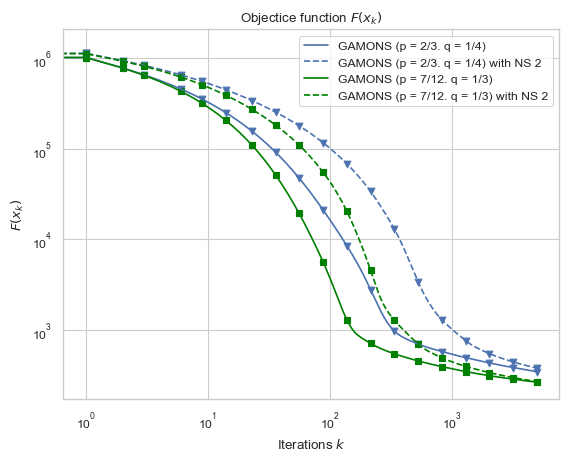

In [24]:
rank = 20
with open(f'results/{dataset}/{dataset}_rank{rank}.pkl', 'rb') as f:
    results_NS6 = pickle.load(f)

with open(f'results/{dataset}/{dataset}_rank{rank}_NS2.pkl', 'rb') as f:
    results_NS2 = pickle.load(f)
    
K = results_NS6['K']
scatter_period = K // 20
D = results_NS6['original']

x = np.arange(K)[::scatter_period]
x = np.logspace(0, np.log10(K-1), num=len(x), endpoint=True).astype(int)

g_NSD6 = results_NS6['gamons (p = 2/3, q = 1/4)']['penalty']
ls_NSD6 = results_NS6['gamons (p = 2/3, q = 1/4)']['loss'] + g_NSD6
plt.loglog(ls_NSD6, color='b', label = 'GAMONS (p = 2/3. q = 1/4)')  
plt.scatter(x, ls_NSD6[x], marker="v", color='b')

g_NSD2 = results_NS2['gamons (p = 2/3, q = 1/4)']['penalty']
ls_NSD2 = results_NS2['gamons (p = 2/3, q = 1/4)']['loss'] + g_NSD2
plt.loglog(ls_NSD2, color='b', linestyle='--', label = 'GAMONS (p = 2/3. q = 1/4) with NS 2')  
plt.scatter(x, ls_NSD2[x], marker="v", color='b')
print(f"Gap GAMONS (p = 2/3. q = 1/4) : {ls_NSD2[-1] - ls_NSD6[-1]:.3e}")

g_NSD6 = results_NS6['gamons (p = 7/12, q = 1/3)']['penalty']
ls_NSD6 = results_NS6['gamons (p = 7/12, q = 1/3)']['loss'] + g_NSD6    
plt.loglog(ls_NSD6, color='green', label = 'GAMONS (p = 7/12. q = 1/3)')  
plt.scatter(x, ls_NSD6[x], marker="s", color='green')
print(f"GAMONS (p = 7/12. q = 1/3) : {ls_NSD6[-1]:.3e}")

g_NSD2 = results_NS2['gamons (p = 7/12, q = 1/3)']['penalty']
ls_NSD2 = results_NS2['gamons (p = 7/12, q = 1/3)']['loss'] + g_NSD2
plt.loglog(ls_NSD2, color='green', linestyle='--', label = 'GAMONS (p = 7/12. q = 1/3) with NS 2')  
plt.scatter(x, ls_NSD2[x], marker="s", color='green')
print(f"Gap GAMONS (p = 7/12. q = 1/3) : {ls_NSD2[-1] - ls_NSD6[-1]:.3e}")


plt.ylabel(r'$F(x_k)$')
plt.xlabel(r'Iterations $k$')
plt.title(r'Objectice function $F(x_k)$')

plt.legend()
plt.show()

Gap GAMONS (p = 2/3. q = 1/4) : 8.257e+01
GAMONS (p = 7/12. q = 1/3) : 2.417e+02
Gap GAMONS (p = 7/12. q = 1/3) : -1.529e+00


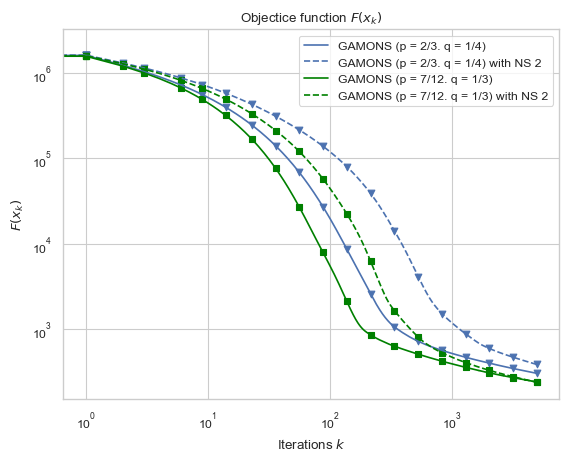

In [25]:
rank = 30
with open(f'results/{dataset}/{dataset}_rank{rank}.pkl', 'rb') as f:
    results_NS6 = pickle.load(f)

with open(f'results/{dataset}/{dataset}_rank{rank}_NS2.pkl', 'rb') as f:
    results_NS2 = pickle.load(f)
    
K = results_NS6['K']
scatter_period = K // 20
D = results_NS6['original']

x = np.arange(K)[::scatter_period]
x = np.logspace(0, np.log10(K-1), num=len(x), endpoint=True).astype(int)

g_NSD6 = results_NS6['gamons (p = 2/3, q = 1/4)']['penalty']
ls_NSD6 = results_NS6['gamons (p = 2/3, q = 1/4)']['loss'] + g_NSD6
plt.loglog(ls_NSD6, color='b', label = 'GAMONS (p = 2/3. q = 1/4)')  
plt.scatter(x, ls_NSD6[x], marker="v", color='b')

g_NSD2 = results_NS2['gamons (p = 2/3, q = 1/4)']['penalty']
ls_NSD2 = results_NS2['gamons (p = 2/3, q = 1/4)']['loss'] + g_NSD2
plt.loglog(ls_NSD2, color='b', linestyle='--', label = 'GAMONS (p = 2/3. q = 1/4) with NS 2')  
plt.scatter(x, ls_NSD2[x], marker="v", color='b')
print(f"Gap GAMONS (p = 2/3. q = 1/4) : {ls_NSD2[-1] - ls_NSD6[-1]:.3e}")

g_NSD6 = results_NS6['gamons (p = 7/12, q = 1/3)']['penalty']
ls_NSD6 = results_NS6['gamons (p = 7/12, q = 1/3)']['loss'] + g_NSD6    
plt.loglog(ls_NSD6, color='green', label = 'GAMONS (p = 7/12. q = 1/3)')  
plt.scatter(x, ls_NSD6[x], marker="s", color='green')
print(f"GAMONS (p = 7/12. q = 1/3) : {ls_NSD6[-1]:.3e}")

g_NSD2 = results_NS2['gamons (p = 7/12, q = 1/3)']['penalty']
ls_NSD2 = results_NS2['gamons (p = 7/12, q = 1/3)']['loss'] + g_NSD2
plt.loglog(ls_NSD2, color='green', linestyle='--', label = 'GAMONS (p = 7/12. q = 1/3) with NS 2')  
plt.scatter(x, ls_NSD2[x], marker="s", color='green')
print(f"Gap GAMONS (p = 7/12. q = 1/3) : {ls_NSD2[-1] - ls_NSD6[-1]:.3e}")


plt.ylabel(r'$F(x_k)$')
plt.xlabel(r'Iterations $k$')
plt.title(r'Objectice function $F(x_k)$')

plt.legend()
plt.show()